In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
hyperdata = {"preprocessing": {}, "complexity": {}, "evaluation": {}}

In [3]:
row_order = [
    "CIC_IDS_2017",
    "CIC_IOT_Dataset2023",
    "IoT_23",
    "IoT_Network_Intrusion_Macro",
    "IoT_Network_Intrusion_Micro",
    "KDD_Cup_1999",
    "UNSW_NB15",
    "BCCC_CIC-BCCC-NRC-ACI-IOT-2023",
    "BCCC_CIC-BCCC-NRC-Edge-IIoTSet-2022",
    "BCCC_CIC-BCCC-NRC-IoMT-2024",
    "BCCC_CIC-BCCC-NRC-IoT-2022",
    "BCCC_CIC-BCCC-NRC-IoT-2023-Original_Training_and_Testing",
    "BCCC_CIC-BCCC-NRC-IoT-HCRL-2019",
    "BCCC_CIC-BCCC-NRC-MQTTIoT-IDS-2020",
    "BCCC_CIC-BCCC-NRC-TONIoT-2021",
    "BCCC_CIC-BCCC-NRC-UQ-IOT-2022",
    "BoT_IoT_Macro",
    "BoT_IoT_Micro",
    "CICAPT_IIoT_Phase1_Macro", # nok (single-class)
    "CICAPT_IIoT_Phase1_Micro", # nok (single-class)
    "CICAPT_IIoT_Phase2_Macro",
    "CICAPT_IIoT_Phase2_Micro",
    "CICEVSE2024_EVSE-A_Macro",
    "CICEVSE2024_EVSE-A_Micro",
    "CICEVSE2024_EVSE-B_Macro",
    "CICEVSE2024_EVSE-B_Micro",
    "CICIoMT2024_Bluetooth",
    "CICIoMT2024_WiFi_and_MQTT",
    "CICIoV2024_Decimal_Macro",
    "CICIoV2024_Decimal_Micro",
    "EDGE-IIOTSET_DNN-EdgeIIoT",
    "EDGE-IIOTSET_ML-EdgeIIoT",
    "MQTT_IoT_IDS2020_BiflowFeatures",
    "MQTT_IoT_IDS2020_PacketFeatures",
    "MQTT_IoT_IDS2020_UniflowFeatures",
    "NIDS_CIC-BoT-IoT",
    "NIDS_CIC-ToN-IoT",
    "NIDS_NF-BoT-IoT",
    "NIDS_NF-BoT-IoT-v2",
    "NIDS_NF-BoT-IoT-v3",
    "NIDS_NF-CICIDS2018-v3",
    "NIDS_NF-CSE-CIC-IDS2018",
    "NIDS_NF-CSE-CIC-IDS2018-v2",
    "NIDS_NF-ToN-IoT",
    "NIDS_NF-ToN-IoT-v2",
    "NIDS_NF-ToN-IoT-v3",
    "NIDS_NF-UNSW-NB15",
    "NIDS_NF-UNSW-NB15-v2",
    "NIDS_NF-UNSW-NB15-v3",
    "NIDS_NF-UQ-NIDS",
    "NIDS_NF-UQ-NIDS-v2",
    "N_BaIoT_Danmini_Doorbell",
    "N_BaIoT_Ecobee_Thermostat",
    "N_BaIoT_Ennio_Doorbell",
    "N_BaIoT_Philips_B120N10_Baby_Monitor",
    "N_BaIoT_Provision_PT_737E_Security_Camera",
    "N_BaIoT_Provision_PT_838_Security_Camera",
    "N_BaIoT_Samsung_SNH_1011_N_Webcam",
    "N_BaIoT_SimpleHome_XCS7_1002_WHT_Security_Camera",
    "N_BaIoT_SimpleHome_XCS7_1003_WHT_Security_Camera",
    "ToN_IoT_IoT_Fridge",
    "ToN_IoT_IoT_GPS_Tracker",
    "ToN_IoT_IoT_Garage_Door",
    "ToN_IoT_IoT_Modbus",
    "ToN_IoT_IoT_Motion_Light",
    "ToN_IoT_IoT_Thermostat",
    "ToN_IoT_IoT_Weather",
    "ToN_IoT_Linux_Disk",
    "ToN_IoT_Linux_Memory",
    "ToN_IoT_Linux_Process",
    "ToN_IoT_Network",
    "ToN_IoT_Windows_10",
    "ToN_IoT_Windows_7"
]

# 1. Phase 1: Preprocessing

In [4]:
PREPROCESSING_ROOT_DIR = "../../2025-11-17/Input_Zip_v4"

In [5]:
for dataset_id in os.listdir(PREPROCESSING_ROOT_DIR):
    if dataset_id not in hyperdata:
        hyperdata["preprocessing"][dataset_id] = {}
    seed_parent_folder = os.path.join(PREPROCESSING_ROOT_DIR, dataset_id, 'Multiclass')
    for seed in os.listdir(seed_parent_folder):
        frac_parent_folder = os.path.join(seed_parent_folder, seed)
        for frac in os.listdir(frac_parent_folder):
            frac_full_folder = os.path.join(frac_parent_folder, frac)
            if frac not in hyperdata["preprocessing"][dataset_id]:
                hyperdata["preprocessing"][dataset_id][frac] = {}
            if seed not in hyperdata["preprocessing"][dataset_id][frac]:
                hyperdata["preprocessing"][dataset_id][frac][seed] = {}
            json_filename = os.path.join(frac_full_folder, f'{dataset_id}.metadata.json')
            with open(json_filename, 'r', encoding='utf-8') as f:
                metadata = json.load(f)
            hyperdata["preprocessing"][dataset_id][frac][seed] = metadata['execution_stats']

In [6]:
preprocessing_rows = []
for dataset_id, fracs in hyperdata["preprocessing"].items():
    for frac_id, seeds in fracs.items():
        for seed_id, stages in seeds.items():
            # 1. Initialize the row with metadata
            row = {
                'dataset': dataset_id,
                'fraction': frac_id,
                'seed': seed_id
            }
            
            # 2. Iterate through stages (e.g., loading_and_sampling, profiling)
            for stage_name, stage_metrics in stages.items():
                
                # 3. Iterate through metrics (e.g., duration_sec, ram_peak_mb)
                for metric_name, metric_value in stage_metrics.items():
                    # Define the column name inside this loop
                    col_name = f"{stage_name}__{metric_name}"
                    
                    # 4. Assign the value to the row
                    row[col_name] = metric_value
                    
                    # if 'KDD' in dataset_id or '2017' in dataset_id or 'Intrusion' in dataset_id:
                    preprocessing_rows.append(row)

            # 5. Append the completed row to the list

# 6. Create the DataFrame
preprocessing_df = pd.DataFrame(preprocessing_rows)
preprocessing_df

,dataset,fraction,seed,loading_and_sampling__duration_sec,loading_and_sampling__cpu_raw_peak,loading_and_sampling__cpu_raw_avg,loading_and_sampling__cpu_norm_peak,loading_and_sampling__cpu_norm_avg,loading_and_sampling__ram_peak_mb,loading_and_sampling__ram_avg_mb,...,splitting__cpu_raw_peak,splitting__cpu_raw_avg,splitting__cpu_norm_peak,splitting__cpu_norm_avg,splitting__ram_peak_mb,splitting__ram_avg_mb,splitting__vram_peak_mb,splitting__vram_avg_mb,splitting__gpu_util_peak,splitting__gpu_util_avg
0,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76280,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76281,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76282,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76283,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# 1. Rename the existing column
preprocessing_df = preprocessing_df.rename(columns={'dataset': 'dataset_name'})

# 2. Convert to Categorical to ensure the sort follows your row_order
preprocessing_df['dataset_name'] = pd.Categorical(preprocessing_df['dataset_name'], categories=row_order, ordered=True)

# 3. Create the dataset_id column based on the index in row_order
# We map the name to its index in the list
name_to_id = {name: i + 1 for i, name in enumerate(row_order)}
preprocessing_df['dataset_id'] = preprocessing_df['dataset_name'].map(name_to_id)

# 4. Sort and reorder columns so IDs and Names are at the front
preprocessing_df = preprocessing_df.sort_values(by=['dataset_id', 'fraction', 'seed']).reset_index(drop=True)

# Move dataset_id and dataset_name to the first and second positions
cols = ['dataset_id', 'dataset_name'] + [c for c in preprocessing_df.columns if c not in ['dataset_id', 'dataset_name']]
preprocessing_df = preprocessing_df[cols]

In [8]:
# 1. Calculate Total Peak RAM across all stages
ram_cols = [c for c in preprocessing_df.columns if '__ram_peak_mb' in c]
preprocessing_df['total_ram_peak_mb'] = preprocessing_df[ram_cols].max(axis=1)

# 2. Calculate Total Duration
duration_cols = [c for c in preprocessing_df.columns if '__duration_sec' in c]
preprocessing_df['total_duration_sec'] = preprocessing_df[duration_cols].sum(axis=1)

# 3. Calculate Average CPU Peak (or Max Peak)
cpu_cols = [c for c in preprocessing_df.columns if '__cpu_raw_peak' in c]
preprocessing_df['total_cpu_peak_max'] = preprocessing_df[cpu_cols].max(axis=1)

In [9]:
preprocessing_df

,dataset_id,dataset_name,fraction,seed,loading_and_sampling__duration_sec,loading_and_sampling__cpu_raw_peak,loading_and_sampling__cpu_raw_avg,loading_and_sampling__cpu_norm_peak,loading_and_sampling__cpu_norm_avg,loading_and_sampling__ram_peak_mb,...,splitting__cpu_norm_avg,splitting__ram_peak_mb,splitting__ram_avg_mb,splitting__vram_peak_mb,splitting__vram_avg_mb,splitting__gpu_util_peak,splitting__gpu_util_avg,total_ram_peak_mb,total_duration_sec,total_cpu_peak_max
0,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
1,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
2,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
3,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
4,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76280,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
76281,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
76282,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
76283,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4


/tmp/ipykernel_9682/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


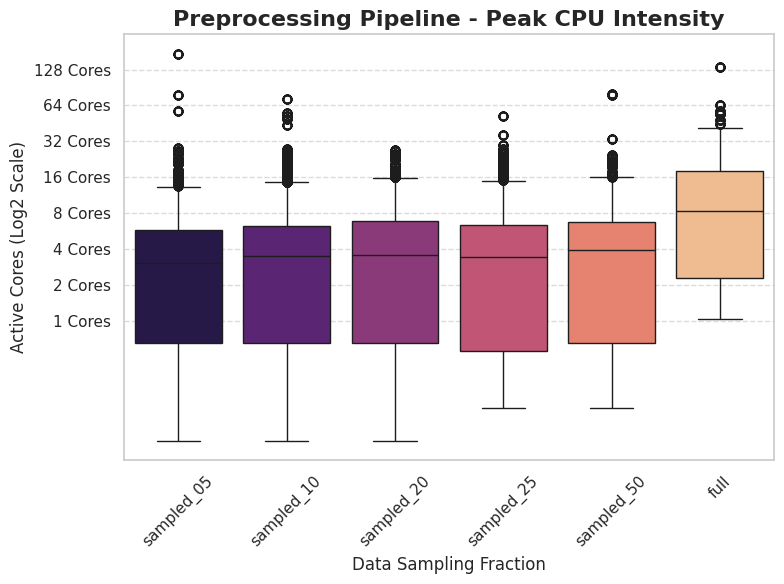

Generated phase_1_preprocessing_cpu.pdf


/tmp/ipykernel_9682/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


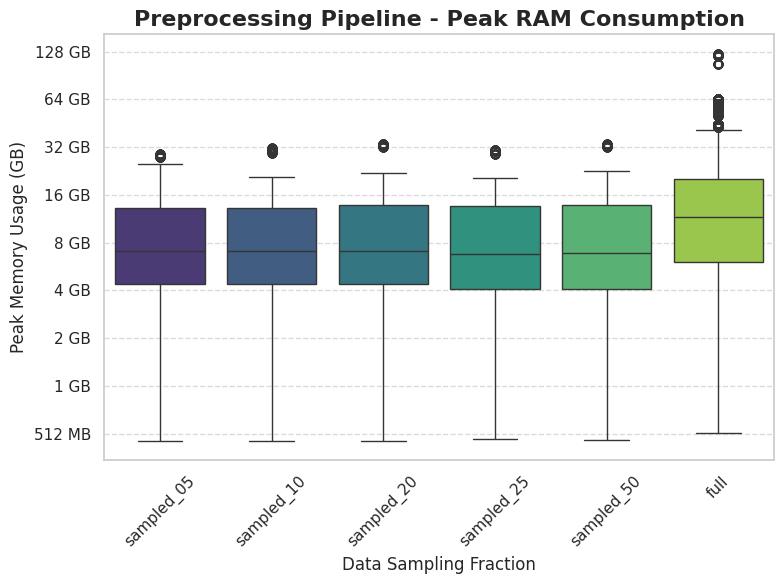

Generated phase_1_preprocessing_ram.pdf


/tmp/ipykernel_9682/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


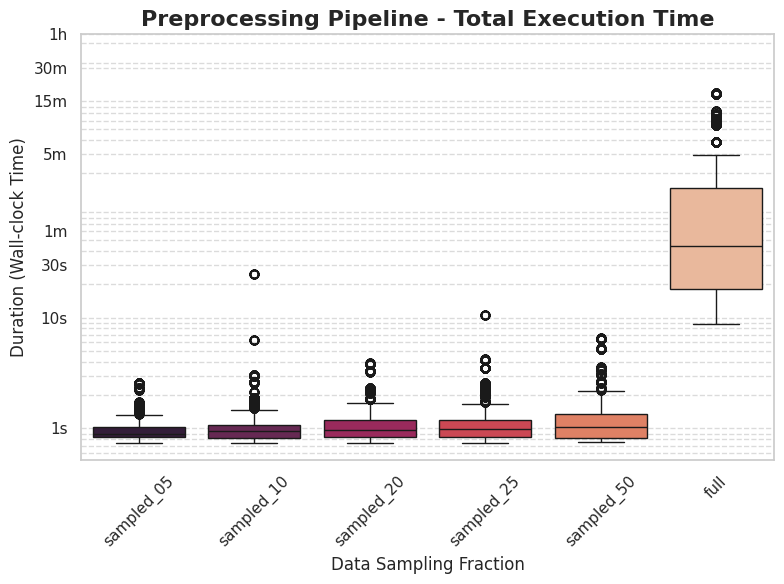

Generated phase_1_preprocessing_time.pdf


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the logical order for fractions
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# --- 1. Define Configurations for each plot ---
# We store all the specific customizations (ticks, labels, palettes) in a list
plot_configs = [
    {
        'col': 'total_cpu_peak_max',
        'title': "Preprocessing Pipeline - Peak CPU Intensity",
        'ylabel': "Active Cores (Log2 Scale)",
        'palette': "magma",
        'scale_base': 2,
        'ticks': [c * 100 for c in [1, 2, 4, 8, 16, 32, 64, 128]],
        'tick_labels': [f'{c} Cores' for c in [1, 2, 4, 8, 16, 32, 64, 128]],
        'filename': 'phase_1_preprocessing_cpu'
    },
    {
        'col': 'total_ram_peak_mb',
        'title': "Preprocessing Pipeline - Peak RAM Consumption",
        'ylabel': "Peak Memory Usage (GB)",
        'palette': "viridis",
        'scale_base': 2,
        'ticks': [g * 1024 for g in [0.5, 1, 2, 4, 8, 16, 32, 64, 128]],
        'tick_labels': [f'{g} GB' if g >= 1 else f'{int(g*1024)} MB' for g in [0.5, 1, 2, 4, 8, 16, 32, 64, 128]],
        'filename': 'phase_1_preprocessing_ram'
    },
    {
        'col': 'total_duration_sec',
        'title': "Preprocessing Pipeline - Total Execution Time",
        'ylabel': "Duration (Wall-clock Time)",
        'palette': "rocket",
        'scale_base': 10,
        'ticks': [1, 10, 30, 60, 300, 900, 1800, 3600],
        'tick_labels': ['1s', '10s', '30s', '1m', '5m', '15m', '30m', '1h'],
        'filename': 'phase_1_preprocessing_time'
    }
]

sns.set_theme(style="whitegrid")

# --- 2. Generation Loop ---
for config in plot_configs:
    
    # Create a new individual figure
    plt.figure(figsize=(8, 6))
    
    # Plotting
    ax = sns.boxplot(
        data=preprocessing_df, 
        x='fraction', 
        y=config['col'], 
        order=fraction_order, 
        palette=config['palette']
    )
    
    # --- Custom Scales & Ticks ---
    ax.set_yscale('log', base=config['scale_base'])
    ax.set_yticks(config['ticks'])
    ax.set_yticklabels(config['tick_labels'])
    
    # --- Formatting ---
    ax.set_title(config['title'], fontsize=16, fontweight='bold')
    ax.set_ylabel(config['ylabel'], fontsize=12)
    ax.set_xlabel("Data Sampling Fraction", fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # Save individually
    full_filename = f"{config['filename']}.pdf"
    plt.savefig(full_filename, dpi=300)
    plt.show()
    plt.close()
    
    print(f"Generated {full_filename}")

In [11]:
# 1. Ensure fractions are in the correct logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# 2. Group by fraction and calculate medians
summary_table = preprocessing_df.groupby('fraction').agg({
    'total_ram_peak_mb': 'median',
    'total_cpu_peak_max': 'median',
    'total_duration_sec': 'median'
}).reindex(fraction_order).reset_index()

# 3. Convert to human-readable units (GB and Cores)
summary_table['Median RAM (GB)'] = (summary_table['total_ram_peak_mb'] / 1024).round(2)
summary_table['Median CPU (Cores)'] = (summary_table['total_cpu_peak_max'] / 100).round(1)
summary_table['Median Time (sec)'] = summary_table['total_duration_sec'].round(2)

# 4. Calculate Efficiency (Time saved vs Full)
full_time = summary_table.loc[summary_table['fraction'] == 'full', 'Median Time (sec)'].values[0]
summary_table['Speedup (x)'] = (full_time / summary_table['Median Time (sec)']).round(1)

# Display the final summary
display(summary_table[['fraction', 'Median RAM (GB)', 'Median CPU (Cores)', 'Median Time (sec)', 'Speedup (x)']])

,fraction,Median RAM (GB),Median CPU (Cores),Median Time (sec),Speedup (x)
0,sampled_05,7.10,3.1,0.90,48.9
1,sampled_10,7.11,3.5,0.94,46.8
2,sampled_20,7.11,3.6,0.97,45.4
3,sampled_25,6.75,3.4,0.98,44.9
4,sampled_50,6.83,3.9,1.04,42.3
5,full,11.61,8.3,44.00,1.0


# Phase 2: Complexity

In [12]:
import os
import json
import pandas as pd

COMPLEXITY_ROOT_DIR = "../../2025-11-17/Output_Zip_v4_Complexity_v3"
fractions_to_exclude = []#'sampled_25', 'sampled_50']
current_fraction_order = [f for f in fraction_order if f not in fractions_to_exclude]

In [13]:
# --- 2. Load and Filter in one pass ---
complexity_rows = []

for dataset_id in os.listdir(COMPLEXITY_ROOT_DIR):
    if '.csv' in dataset_id: continue
    
    seed_parent_folder = os.path.join(COMPLEXITY_ROOT_DIR, dataset_id, 'Multiclass')
    if not os.path.exists(seed_parent_folder): continue

    for seed in os.listdir(seed_parent_folder):
        frac_parent_folder = os.path.join(seed_parent_folder, seed)
        for frac in os.listdir(frac_parent_folder):
            
            # Skip excluded fractions immediately
            if frac in fractions_to_exclude:
                continue
                
            json_filename = os.path.join(frac_parent_folder, frac, f'{dataset_id}_X_y.complexity.json')
            
            if os.path.exists(json_filename):
                with open(json_filename, 'r', encoding='utf-8') as f:
                    metadata = json.load(f)
                
                # Initialize row
                row = {'dataset_name': dataset_id, 'fraction': frac, 'seed': seed}
                
                # Flatten execution stats
                stats = metadata.get('execution_stats', {})
                for stage_name, stage_metrics in stats.items():
                    if stage_name.endswith('_end'):
                        for metric_name, metric_value in stage_metrics.items():
                            row[f"{stage_name}__{metric_name}"] = metric_value

                complexity_rows.append(row)

In [14]:
# --- 3. Create DataFrame and Set Types ---
complexity_df = pd.DataFrame(complexity_rows)

# Cast to categorical (fixes the .cat Attribute error and the x-axis empty ticks)
complexity_df['fraction'] = pd.Categorical(
    complexity_df['fraction'], 
    categories=current_fraction_order, 
    ordered=True
)

In [15]:
cpu_cols

['loading_and_sampling__cpu_raw_peak',
 'transformation__cpu_raw_peak',
 'profiling__cpu_raw_peak',
 'loading_and_cleaning__cpu_raw_peak',
 'splitting__cpu_raw_peak']

In [16]:
gpu_cols

NameError: name 'gpu_cols' is not defined

In [17]:
dur_cols

NameError: name 'dur_cols' is not defined

In [ ]:
# --- 4. Aggregations ---

# CPU
cpu_cols = [c for c in complexity_df.columns if '__cpu_raw_peak' in c]
complexity_df['complexity_cpu_peak_max'] = complexity_df[cpu_cols].max(axis=1)

# RAM
ram_cols = [c for c in complexity_df.columns if '__ram_peak_mb' in c]
complexity_df['complexity_ram_peak_mb'] = complexity_df[ram_cols].max(axis=1)

# GPU
gpu_cols = [c for c in complexity_df.columns if '__gpu_util_peak' in c]
complexity_df['complexity_gpu_peak_max'] = complexity_df[gpu_cols].max(axis=1)

# VRAM
vram_cols = [c for c in complexity_df.columns if '__vram_peak_mb' in c]
complexity_df['complexity_vram_peak_mb'] = complexity_df[vram_cols].max(axis=1)

# Duration
dur_cols = [c for c in complexity_df.columns if '__duration_sec' in c]
complexity_df['complexity_duration_sec'] = complexity_df[dur_cols].sum(axis=1)

# --- 5. CLEANING: Remove Failed Runs ---
# valid_run = (RAM > 0) AND (Duration > 0)
# We do NOT filter on GPU because 0 GPU usage is a valid scientific finding.
complexity_df = complexity_df[
    (complexity_df['complexity_ram_peak_mb'] > 0) & 
    (complexity_df['complexity_duration_sec'] > 0)
].copy()

# Optional: Print how many rows were dropped
print(f"Remaining valid rows: {len(complexity_df)}")

In [ ]:
# --- 1. Define Scale-Specific Ticks ---

# CPU: 1 to 64 Cores
cpu_cores = [1, 2]
cpu_ticks = [c * 100 for c in cpu_cores]
cpu_labels = [f'{c} Cores' for c in cpu_cores]

# RAM: 1GB to 4GB
ram_gb = [1, 1.5]
ram_ticks = [g * 1024 for g in ram_gb]
ram_labels = [f'{g}GB' for g in ram_gb]

# VRAM: 256MB to 2GB
vram_gb = [0.25, 0.5, 1, 2, 4, 8, 16, 32]
vram_ticks = [g * 1024 for g in vram_gb]
vram_labels = [f'{int(g*1024)}MB' if g < 1 else f'{g}GB' for g in vram_gb]

# Duration: 1s to 2h (Log scale)
time_vals = [1, 10, 60]
time_labels = ['1s', '10s', '1m']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- 1. Configurations ---
# (column_name, title, palette, ticks, labels, log_base)
plot_configs = [
    ('complexity_cpu_peak_max', 'Max CPU Burst (%)', 'magma', None, None, 2),
    ('complexity_ram_peak_mb', 'Peak System RAM', 'viridis', None, None, 2),
    ('complexity_gpu_peak_max', 'Max GPU Utilization (%)', 'rocket', None, None, None),
    ('complexity_vram_peak_mb', 'Peak GPU VRAM', 'plasma', None, None, 2),
    ('complexity_duration_sec', 'Total Execution Time', 'cividis', None, None, 10)
]

sns.set_theme(style="whitegrid")

# --- 2. Generation Loop ---
for col, title, pal, ticks, labels, log_base in plot_configs:
    
    # 1. FILTERING: Remove valid errors (0s)
    clean_data = complexity_df[complexity_df[col] > 0].copy()

    # 2. WINSORIZATION
    # Soft clip to keep the distribution shape reasonable
    low_limit = clean_data[col].quantile(0.01)
    high_limit = clean_data[col].quantile(0.99)
    clean_data[col] = clean_data[col].clip(lower=low_limit, upper=high_limit)
    
    # Check if this is the duration plot to double the width
    width = 16 if 'duration' in col else 8
    plt.figure(figsize=(width, 6))
    
    # 3. VIOLIN PLOT
    ax = sns.violinplot(
        data=clean_data,
        x='fraction',
        y=col,
        order=current_fraction_order,
        hue='fraction',
        palette=pal,
        legend=False,
        inner='quartile', # Draw median and quartiles
        linewidth=1.5,
        cut=0             # Prevent tails from going to infinity/negative
    )
    
    # Standard Formatting
    plt.title(title, fontweight='bold', fontsize=18 if width > 8 else 16)
    plt.xlabel("Sampling Rate", fontsize=12)
    plt.ylabel("")
    plt.xticks(rotation=45)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)

    # --- SCALING LOGIC (Identical to Boxplots) ---
    
    # 1. VRAM (Check first!)
    if 'vram' in col:
        plt.yscale('linear')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1024:.0f} GB'))
        
    # 2. GPU Utilization
    elif 'gpu_peak_max' in col:
        plt.ylim(-5, 105)

    # 3. CPU (Linear %)
    elif 'cpu' in col:
        plt.yscale('linear')
        # plt.ylim(75, 180) # Optional: unlock this if violin tails get cut off
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))

    # 4. RAM (System)
    elif 'ram_peak_mb' in col:
        plt.yscale('linear')
        # Zoom to the clipped range
        plt.ylim(low_limit * 0.99, high_limit * 1.01)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)} MB'))
        
    # 5. Time (Duration)
    elif 'duration' in col:
        plt.yscale('linear')
        y_max = clean_data[col].max() * 1.1 
        plt.ylim(0, y_max)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}s'))
    
    plt.tight_layout()
    
    # Save as separate PDF
    filename = f"phase_2_violin_{col}.pdf"
    plt.savefig(filename, format='pdf', dpi=300)
    plt.show()
    plt.close()
    
    print(f"Generated {filename}")

In [ ]:
# --- Configuration for the Table ---
# We focus on the median values for a robust comparison
table_cols = {
    'complexity_cpu_peak_max': 'CPU (%)',
    'complexity_ram_peak_mb': 'RAM (MB)',
    'complexity_vram_peak_mb': 'VRAM (GB)',  # converting to GB to match plot
    'complexity_duration_sec': 'Time (s)'
}

# 1. Group by Fraction and Calculate Median
summary = complexity_df.groupby('fraction')[list(table_cols.keys())].median()

# 2. Rename Columns
summary = summary.rename(columns=table_cols)

# 3. Unit Conversions (Matching your plots)
# CPU is already in % (e.g., 100.0)
# RAM is already in MB
# VRAM: MB -> GB
summary['VRAM (GB)'] = summary['VRAM (GB)'] / 1024
# Time: Seconds (already correct)

# 4. Calculate Speedup (Efficiency)
# How many times faster is this fraction compared to 'full'?
full_time = summary.loc['full', 'Time (s)']
summary['Speedup (x)'] = full_time / summary['Time (s)']

# 5. Format for LaTeX
# Rounding for cleanliness
summary['CPU (%)'] = summary['CPU (%)'].round(2)
summary['RAM (MB)'] = summary['RAM (MB)'].round(2).astype(int)
summary['VRAM (GB)'] = summary['VRAM (GB)'].round(2)
summary['Time (s)'] = summary['Time (s)'].round(2)
summary['Speedup (x)'] = summary['Speedup (x)'].round(2)

# Reorder for logical flow
final_table = summary[['RAM (MB)', 'CPU (%)', 'VRAM (GB)', 'Time (s)', 'Speedup (x)']]

# 6. Generate LaTeX
print("-" * 30)
print("LaTeX Table Code:")
print("-" * 30)
print(final_table.to_latex(float_format="%.1f"))
print("-" * 30)

# Display readable version
display(final_table)

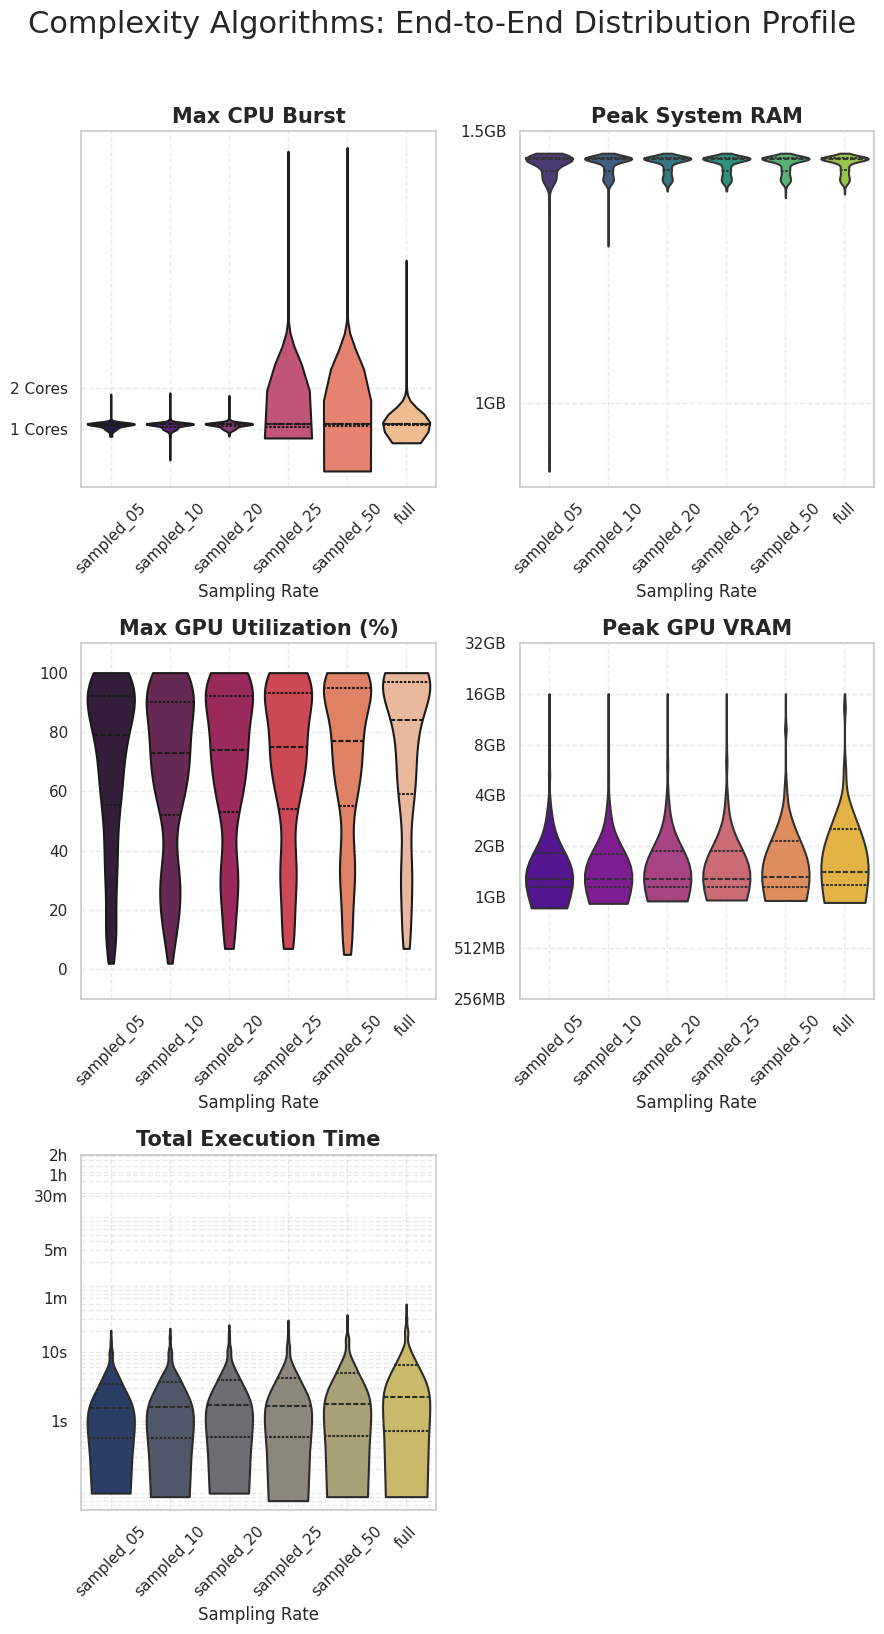

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Violin Plotting Logic ---

fig, axes = plt.subplots(3, 2, figsize=(9, 16))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

plot_configs = [
    ('complexity_cpu_peak_max', 'Max CPU Burst', 'magma', cpu_ticks, cpu_labels),
    ('complexity_ram_peak_mb', 'Peak System RAM', 'viridis', ram_ticks, ram_labels),
    ('complexity_gpu_peak_max', 'Max GPU Utilization (%)', 'rocket', None, None),
    ('complexity_vram_peak_mb', 'Peak GPU VRAM', 'plasma', vram_ticks, vram_labels),
    ('complexity_duration_sec', 'Total Execution Time', 'cividis', time_vals, time_labels)
]

for i, (col, title, pal, ticks, labels) in enumerate(plot_configs):
    # Using violinplot instead of boxplot
    sns.violinplot(
        ax=axes[i],
        data=complexity_df,
        x='fraction',
        y=col,
        order=current_fraction_order,
        hue='fraction',
        palette=pal,
        legend=False,
        inner='quartile', # Shows median and quartiles inside the violin
        linewidth=1.5,
        cut=0              # Limits the violin to the actual data range (prevents "impossible" tails)
    )
    
    axes[i].set_title(title, fontweight='bold', fontsize=15)
    
    # Scaling Logic
    if 'gpu_peak_max' in col:
        axes[i].set_ylim(-10, 110) # Added a bit of padding for violin curves
    else:
        if complexity_df[col].max() > 0:
            base = 10 if 'duration' in col else 2
            axes[i].set_yscale('log', base=base)
            if ticks:
                axes[i].set_yticks(ticks)
                axes[i].set_yticklabels(labels)
        else:
            axes[i].text(0.5, 0.5, 'No Usage Data', transform=axes[i].transAxes, 
                         ha='center', fontsize=12, color='gray')

# Hide the empty 6th slot
axes[5].set_visible(False)

for ax in axes[:5]:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("")

plt.suptitle("Complexity Algorithms: End-to-End Distribution Profile", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig('phase_2_complexity_violin.png', dpi=150)
plt.show()

In [21]:
df

NameError: name 'df' is not defined

In [ ]:
# 1. Identify all metric columns (the ones we created with stage__metric)
metric_cols = [c for c in df.columns if '__' in c]

# 2. Filter that list to keep only those with NO NaNs
plottable_metrics = [col for col in metric_cols if df[col].notna().all()]

print(f"Total metrics: {len(metric_cols)}")
print(f"Metrics without NaNs (Safe for plotting): {len(plottable_metrics)}")

# 3. If you want to see which ones were dropped:
dropped_metrics = list(set(metric_cols) - set(plottable_metrics))
print(f"Dropped due to NaNs: {dropped_metrics}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through the first 5 clean metrics as an example
for metric in plottable_metrics:
    plt.figure(figsize=(15, 6))
    
    sns.lineplot(
        data=df, 
        x='dataset_id', 
        y=metric, 
        hue='fraction', 
        marker='o'
    )
    
    plt.xticks(range(1, 74), rotation=90, fontsize=7)
    plt.title(f"Comparison of {metric}")
    plt.tight_layout()
    
    # Save each plot automatically
    file_name = f"profiling/plot_{metric.replace('__', '_')}.png"
    plt.savefig(file_name)
    plt.close() # Close to save memory

In [ ]:
# 1. Calculate Total Peak RAM across all stages
ram_cols = [c for c in df.columns if '__ram_peak_mb' in c]
df['total_ram_peak_mb'] = df[ram_cols].max(axis=1)

# 2. Calculate Total Duration
duration_cols = [c for c in df.columns if '__duration_sec' in c]
df['total_duration_sec'] = df[duration_cols].sum(axis=1)

# 3. Calculate Average CPU Peak (or Max Peak)
cpu_cols = [c for c in df.columns if '__cpu_raw_peak' in c]
df['total_cpu_peak_max'] = df[cpu_cols].max(axis=1)

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Set logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# Use the new AGGREGATED column here
# Change 'total_ram_peak_mb' to 'total_cpu_peak_max' to see the CPU version
sns.boxplot(
    data=df, 
    x='fraction', 
    y='total_ram_peak_mb', 
    order=fraction_order, 
    palette="viridis",
    showfliers=True  # Keep the outliers visible
)

# 3. SCALE IMPROVEMENT: Log scale is essential for RAM
# This prevents the 'full' dataset from squashing the 'sampled' bars to 0
plt.yscale('log')

# 4. FORMATTING
plt.title("Total Pipeline Resource Consumption: Sampling vs. Full Dataset", fontsize=15, pad=15)
plt.ylabel("Peak RAM (MB) - Log Scale", fontsize=12)
plt.xlabel("Sampling Rate", fontsize=12)
plt.grid(True, which="both", axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the fractions are in the correct logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plotting the RAM peak for the 'splitting' stage
sns.boxplot(
    data=df, 
    x='fraction', 
    y='profiling__ram_peak_mb', 
    order=fraction_order, 
    palette="magma"
)

plt.title("Peak RAM Usage Distribution: Sampling vs. Full Dataset (Splitting Stage)", fontsize=14)
plt.ylabel("Peak RAM (MB)")
plt.xlabel("Sampling Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("ram_peak_boxplot.png", dpi=300)
plt.show()